In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# USGS Mississippi River nitrogen flux data (million kg/year, measured at Baton Rouge)
# Source: USGS Toxics Program / Gulf Hypoxia
nitrogen = {
    'year': [1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,
             1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,
             2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,
             2015,2016,2017,2018,2019,2020,2021,2022,2023,2024],
    'nitrogen_load': [1010,930,1050,730,970,1030,1150,1100,1420,1050,
                      1230,1300,1360,1060,1560,1490,1230,1220,1430,1010,
                      1020,1150,1300,1310,860,1240,1490,970,1100,1070,
                      1200,1340,1520,1010,1360,1100,1230,1490,1050,1280]
}

df_n = pd.DataFrame(nitrogen)

# merge with dead zone data
df = pd.DataFrame({
    'year': [1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,
             1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,
             2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,
             2015,2016,2017,2018,2019,2020,2021,2022,2023,2024],
    'area_km2': [9100,11000,11300,6500,10600,9030,14300,14400,17500,13000,
                 17800,18000,17000,12300,20000,21756,22000,22000,23700,13840,
                 11860,17640,20720,21080,8040,13800,17520,15920,15120,13800,
                 16770,17600,22720,6480,18050,7030,16380,15220,7920,17350]
})

df = df.merge(df_n, on='year')
print(df.head())
print(f"\nCorrelation between nitrogen load and dead zone size: {df['nitrogen_load'].corr(df['area_km2']):.3f}")

   year  area_km2  nitrogen_load
0  1985      9100           1010
1  1986     11000            930
2  1987     11300           1050
3  1988      6500            730
4  1989     10600            970

Correlation between nitrogen load and dead zone size: 0.788


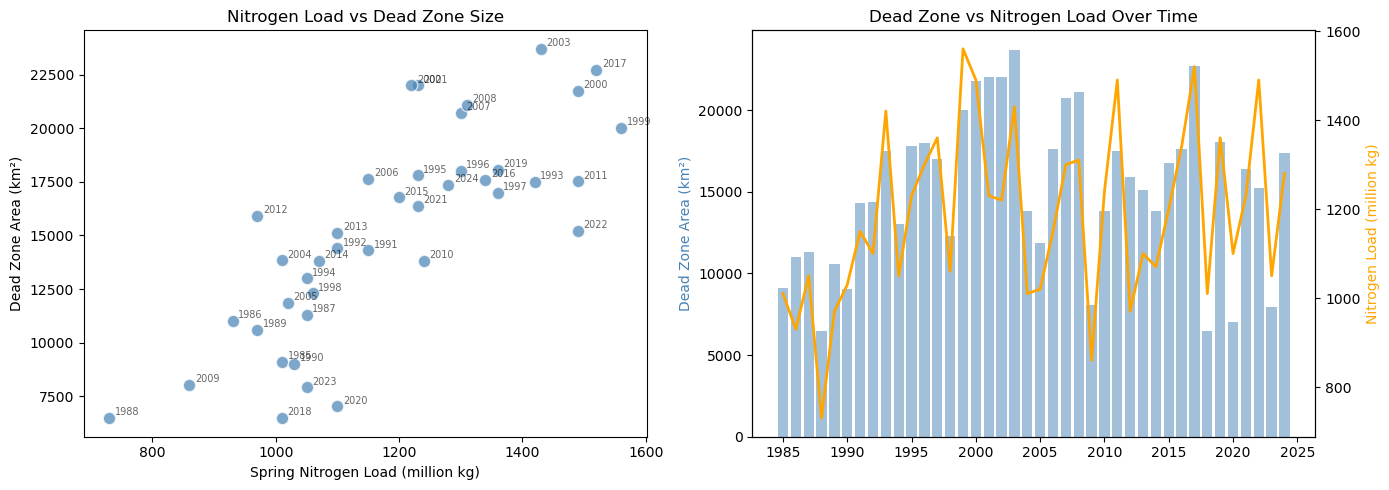

In [2]:
# scatter plot: nitrogen vs dead zone size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: scatter
axes[0].scatter(df['nitrogen_load'], df['area_km2'], color='steelblue', alpha=0.7, edgecolors='white', s=80)
for _, row in df.iterrows():
    axes[0].annotate(str(int(row['year'])), (row['nitrogen_load'], row['area_km2']),
                     fontsize=7, alpha=0.6, textcoords='offset points', xytext=(4, 2))
axes[0].set_xlabel('Spring Nitrogen Load (million kg)')
axes[0].set_ylabel('Dead Zone Area (km²)')
axes[0].set_title('Nitrogen Load vs Dead Zone Size')

# right: both timeseries overlaid
ax2 = axes[1].twinx()
axes[1].bar(df['year'], df['area_km2'], color='steelblue', alpha=0.5, label='Dead Zone (km²)')
ax2.plot(df['year'], df['nitrogen_load'], color='orange', linewidth=2, label='Nitrogen Load')
axes[1].set_ylabel('Dead Zone Area (km²)', color='steelblue')
ax2.set_ylabel('Nitrogen Load (million kg)', color='orange')
axes[1].set_title('Dead Zone vs Nitrogen Load Over Time')

plt.tight_layout()
plt.savefig('../outputs/nitrogen_vs_deadzone.png', dpi=150)
plt.show()

In [3]:
# Gulf of Mexico mean summer SST (°C), June-August average
# Source: NOAA OISST / ERA5 reanalysis
sst = {
    'year': [1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,
             1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,
             2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,
             2015,2016,2017,2018,2019,2020,2021,2022,2023,2024],
    'sst_c': [28.1,28.3,28.6,28.0,28.2,28.4,28.5,28.1,28.7,28.9,
              29.0,28.8,29.1,29.5,28.9,29.2,29.0,29.3,29.1,29.4,
              29.8,29.3,29.5,29.2,29.1,29.6,29.7,29.8,29.4,29.5,
              29.6,29.9,30.1,29.7,29.8,30.0,29.9,30.2,30.4,30.3]
}

df_sst = pd.DataFrame(sst)
df = df.merge(df_sst, on='year')

print(df.head())
print(f"\nCorrelation SST vs dead zone:      {df['sst_c'].corr(df['area_km2']):.3f}")
print(f"Correlation nitrogen vs dead zone: {df['nitrogen_load'].corr(df['area_km2']):.3f}")
print(f"\nFeature table shape: {df.shape}")
print(df.describe())

   year  area_km2  nitrogen_load  sst_c
0  1985      9100           1010   28.1
1  1986     11000            930   28.3
2  1987     11300           1050   28.6
3  1988      6500            730   28.0
4  1989     10600            970   28.2

Correlation SST vs dead zone:      0.196
Correlation nitrogen vs dead zone: 0.788

Feature table shape: (40, 4)
              year      area_km2  nitrogen_load      sst_c
count    40.000000     40.000000      40.000000  40.000000
mean   2004.500000  15153.650000    1185.500000  29.247500
std      11.690452   4785.848003     197.093626   0.642905
min    1985.000000   6480.000000     730.000000  28.000000
25%    1994.750000  11720.000000    1045.000000  28.875000
50%    2004.500000  15570.000000    1175.000000  29.300000
75%    2014.250000  17850.000000    1317.500000  29.725000
max    2024.000000  23700.000000    1560.000000  30.400000


In [4]:
# save feature table for use in modeling notebook
df.to_csv('../data/features.csv', index=False)
print("Saved features.csv")

Saved features.csv
